## Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Read Dataset

In [ ]:
df = pd.read_csv("imdb_traffic.csv")

df.head()

,Year,Month,Total_Estimated_Visits,Active_Logged_In_Users,Unique_Users_Rating,Total_Ratings_Submitted,Total_Page_Views,Avg_Session_Duration_Sec
0,2010,January,102483570,15006167,1663546,9331459,589981535,287.6
1,2010,February,106828680,15176123,1695689,9866151,666516233,287.9
2,2010,March,116268827,16444615,1888672,10483181,687969529,241.0
3,2010,April,122675155,17405828,1982592,11447421,691427174,285.2
4,2010,May,111899622,16970404,1890722,10951022,643999625,291.2


## Dataset Information

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Year                      10000 non-null  int64  
 1   Month                     10000 non-null  object 
 2   Total_Estimated_Visits    10000 non-null  int64  
 3   Active_Logged_In_Users    10000 non-null  int64  
 4   Unique_Users_Rating       10000 non-null  int64  
 5   Total_Ratings_Submitted   10000 non-null  int64  
 6   Total_Page_Views          10000 non-null  int64  
 7   Avg_Session_Duration_Sec  10000 non-null  float64
dtypes: float64(1), int64(6), object(1)
memory usage: 625.1+ KB


## Check Missing Values

In [ ]:
df.isnull().sum()

Year                        0
Month                       0
Total_Estimated_Visits      0
Active_Logged_In_Users      0
Unique_Users_Rating         0
Total_Ratings_Submitted     0
Total_Page_Views            0
Avg_Session_Duration_Sec    0
dtype: int64

## Statistical Summary

In [ ]:
df.describe()

,Year,Total_Estimated_Visits,Active_Logged_In_Users,Unique_Users_Rating,Total_Ratings_Submitted,Total_Page_Views,Avg_Session_Duration_Sec
count,10000.000000,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04,10000.000000
mean,2426.166800,1.999929e+08,3.003657e+07,3.378472e+06,1.942630e+07,1.199769e+09,270.072440
std,240.574699,5.887996e+07,8.952471e+06,1.007718e+06,5.820201e+06,3.591168e+08,17.256617
min,2010.000000,7.604381e+07,1.133372e+07,1.284439e+06,7.404661e+06,4.621589e+08,240.000000
25%,2218.000000,1.500188e+08,2.242917e+07,2.525112e+06,1.452242e+07,8.964948e+08,255.500000
50%,2426.000000,1.994917e+08,2.997140e+07,3.365482e+06,1.937230e+07,1.196391e+09,270.000000
75%,2634.250000,2.500078e+08,3.744486e+07,4.212490e+06,2.421168e+07,1.497623e+09,285.100000
max,2843.000000,3.211633e+08,5.114488e+07,5.773075e+06,3.439335e+07,2.076753e+09,300.000000


## Correlation Matrix

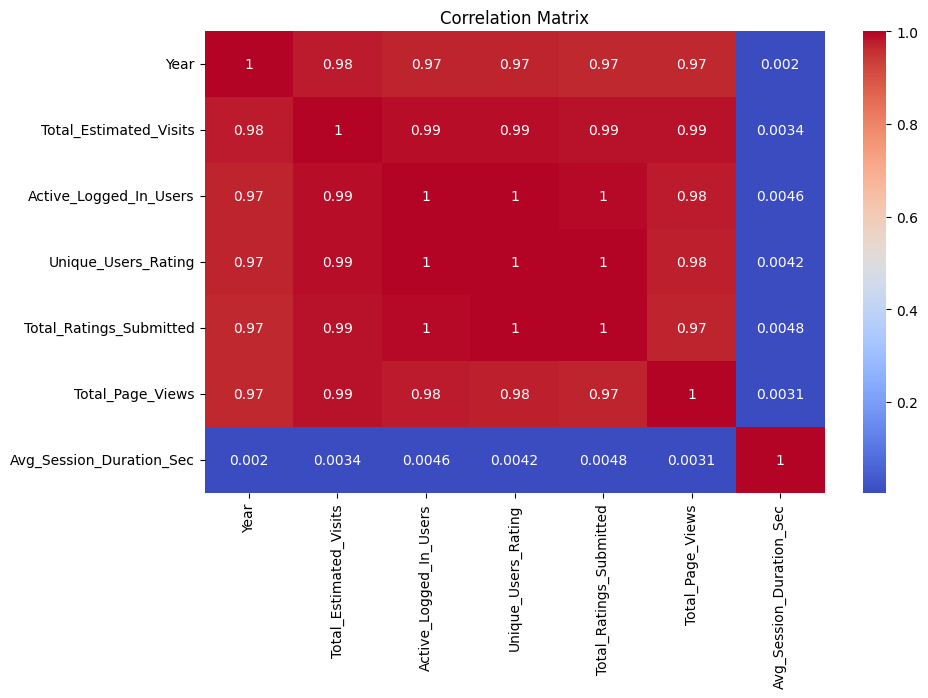

In [ ]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")
plt.show()

## Distribution of Visits

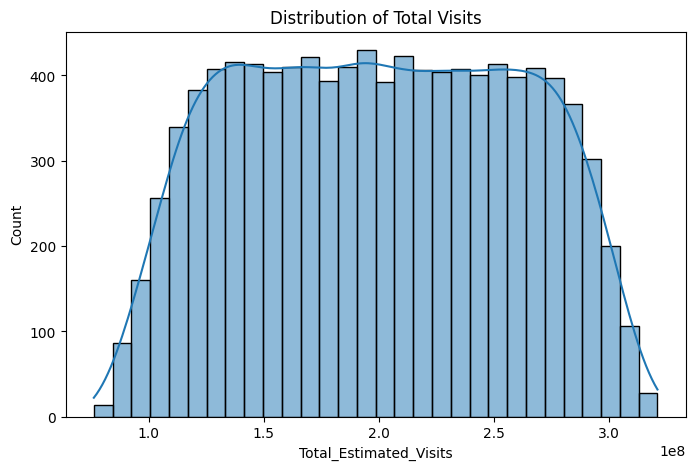

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Total_Estimated_Visits"],
    bins=30,
    kde=True
)

plt.title("Distribution of Total Visits")
plt.show()

## Page Views vs Visits

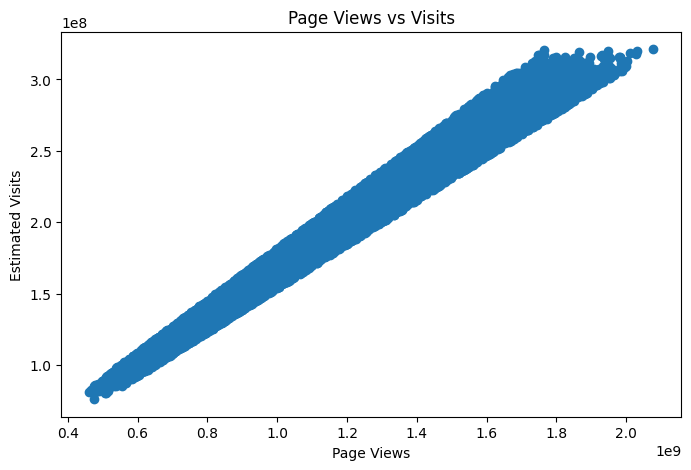

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["Total_Page_Views"],
    df["Total_Estimated_Visits"]
)

plt.xlabel("Page Views")
plt.ylabel("Estimated Visits")
plt.title("Page Views vs Visits")

plt.show()

## Select Features and Target

In [ ]:
X = df[
    [
        "Active_Logged_In_Users",
        "Unique_Users_Rating",
        "Total_Ratings_Submitted",
        "Total_Page_Views",
        "Avg_Session_Duration_Sec"
    ]
]

y = df["Total_Estimated_Visits"]

## Split Data

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Train Random Forest Model

In [ ]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

## Make Predictions

In [ ]:
y_pred = rf.predict(X_test)

## Evaluate Model

In [ ]:
print("MAE :", mean_absolute_error(y_test, y_pred))

print("RMSE :",
      np.sqrt(mean_squared_error(y_test, y_pred)))

print("R2 Score :",
      r2_score(y_test, y_pred))

MAE : 4916775.150559999
RMSE : 6270133.720839156
R2 Score : 0.9886375425001054


## Actual vs Predicted

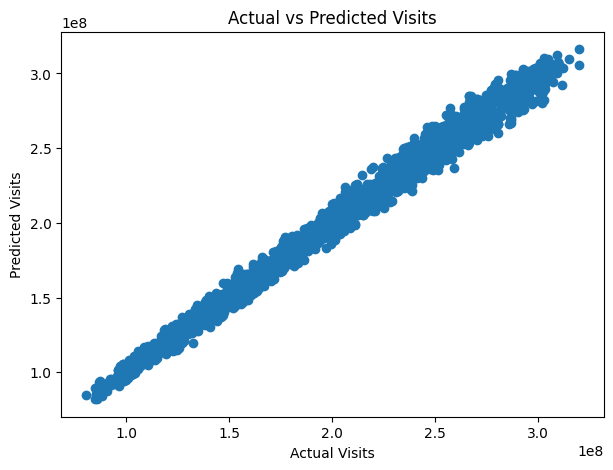

In [ ]:
plt.figure(figsize=(7,5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Visits")
plt.ylabel("Predicted Visits")
plt.title("Actual vs Predicted Visits")

plt.show()

## Feature Importance

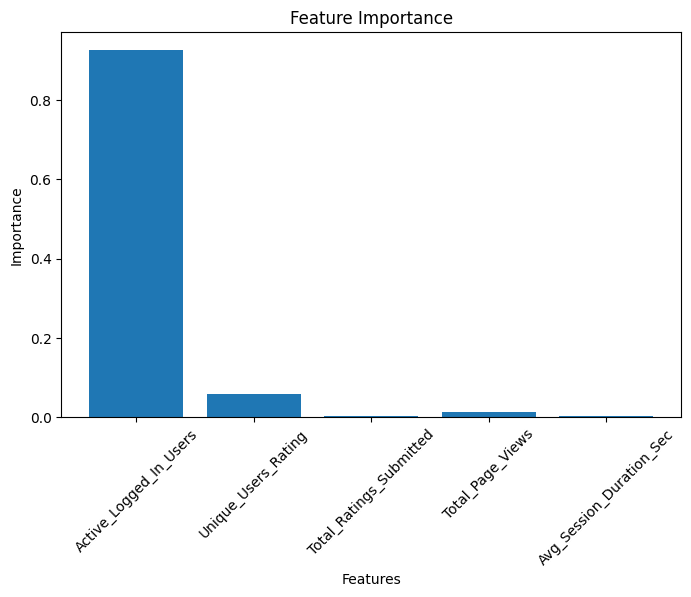

In [ ]:
importance = rf.feature_importances_

features = X.columns

plt.figure(figsize=(8,5))

plt.bar(features, importance)

plt.xticks(rotation=45)

plt.xlabel("Features")
plt.ylabel("Importance")

plt.title("Feature Importance")

plt.show()

## Predict New Data

In [ ]:
sample = [[
    25000,   # Active users
    12000,   # Unique ratings
    18000,   # Ratings submitted
    500000,  # Page views
    320      # Session duration
]]

prediction = rf.predict(sample)

print("Predicted Visits:", prediction[0])

Predicted Visits: 78732664.84


c:\Users\souri krishna\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
